# Classification Track (Part A) - Urban Bike Demand Forecasting

### Problem Statement

Predict the bike rental demand category for an urban bike-sharing system using information such as weather conditions, temperature, humidity, wind speed, time of day, day of the week, and other environmental and temporal features.

The original `count` variable represents the total number of bike rentals. For the classification task, this continuous demand is converted into four categories: **Low, Medium, High, and Very High**, allowing the model to predict the demand level rather than an exact rental count.

### Dataset

**Capital Bike Share Dataset** — `capitalbikeshare-complete.csv`

The dataset contains **33,379 records and 16 original columns**, including datetime, bike rental count, weather conditions, temperature, humidity, wind speed, and other environmental attributes.

**Target for Classification:** `demand_class`

**Classes:**
- Low
- Medium
- High
- Very High

### Scope of this Notebook

Review 1 covers **Classification Part A**: implementation and evaluation of the first five classification algorithms:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine (SVM)

### Notebook Map

| Section | Contents |
|---|---|
| 1 | Load & Audit |
| 2 | Exploratory Data Analysis |
| 3 | Data Cleaning |
| 4 | Feature Engineering |
| 5 | Encoding, Scaling & Train-Test Split |
| 6 | Classification Target & Class Distribution |
| 7 | Five Classification Algorithms |
| 8 | Comparative Evaluation |
| 9 | Cross-Validation |
| 10 | Conclusion |


In [49]:
#  Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import LinearSVC

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")
print("Random State:", RANDOM_STATE)

Libraries imported successfully.
Random State: 42


In [2]:
file_path = "capitalbikeshare-complete.csv"
df = pd.read_csv(file_path)
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (33379, 16)


In [3]:
display(df.head())

,datetime,count,holiday,workingday,temp,feels_like,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,snow_1h,clouds_all,weather_main
0,2018-01-01 00:00,34,1,0,-7.17,-12.73,-8.56,-7.09,1030,53,3.6,310,NaN,NaN,20,Clouds
1,2018-01-01 01:00,49,1,0,-7.35,-13.81,-9.03,-7.15,1030,49,4.6,310,NaN,NaN,1,Clear
2,2018-01-01 02:00,37,1,0,-7.88,-14.05,-9.03,-7.69,1031,52,4.1,310,NaN,NaN,1,Clear
3,2018-01-01 03:00,9,1,0,-8.10,-14.32,-9.36,-7.89,1031,49,4.1,310,NaN,NaN,1,Clear
4,2018-01-01 04:00,12,1,0,-8.19,-14.43,-9.46,-8.09,1031,49,4.1,330,NaN,NaN,1,Clear


In [4]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

DATASET INFORMATION
Rows and Columns: (33379, 16)

Column Names:
['datetime', 'count', 'holiday', 'workingday', 'temp', 'feels_like', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main']

Data Types:
datetime            str
count             int64
holiday           int64
workingday        int64
temp            float64
feels_like      float64
temp_min        float64
temp_max        float64
pressure          int64
humidity          int64
wind_speed      float64
wind_deg          int64
rain_1h         float64
snow_1h         float64
clouds_all        int64
weather_main        str
dtype: object


In [5]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

display(missing_values)

,Missing Values,Missing Percentage
datetime,0,0.000000
count,0,0.000000
holiday,0,0.000000
workingday,0,0.000000
temp,0,0.000000
feels_like,0,0.000000
temp_min,0,0.000000
temp_max,0,0.000000
pressure,0,0.000000
humidity,0,0.000000


In [6]:
#  Duplicate Check
print("Number of completely duplicated rows:", df.duplicated().sum())

Number of completely duplicated rows: 0


In [7]:
# Statistical Summary
display(df.describe())

,count,holiday,workingday,temp,feels_like,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,snow_1h,clouds_all
count,33379.000000,33379.000000,33379.000000,33379.000000,33379.000000,33379.000000,33379.000000,33379.000000,33379.000000,33379.000000,33379.000000,6771.000000,326.000000,33379.000000
mean,333.139788,0.030618,0.681327,15.213087,14.994843,13.532648,16.105542,1017.071602,67.818628,1.829340,174.022919,1.213968,0.641380,63.213997
std,336.519514,0.172283,0.465969,9.908964,11.176487,9.993094,9.984839,7.379420,18.422105,1.703747,113.844334,2.001427,0.571087,30.825936
min,0.000000,0.000000,0.000000,-12.790000,-18.910000,-15.140000,-12.290000,980.000000,14.000000,0.000000,0.000000,0.100000,0.100000,0.000000
25%,59.000000,0.000000,0.000000,6.860000,5.880000,5.230000,7.730000,1012.000000,53.000000,0.450000,62.000000,0.250000,0.250000,40.000000
50%,236.000000,0.000000,1.000000,15.650000,15.020000,13.910000,16.590000,1017.000000,70.000000,1.340000,180.000000,0.530000,0.420000,75.000000
75%,495.000000,0.000000,1.000000,23.800000,24.140000,21.970000,24.390000,1022.000000,84.000000,2.600000,285.000000,1.300000,1.000000,90.000000
max,2038.000000,1.000000,1.000000,36.710000,43.710000,35.380000,38.810000,1044.000000,100.000000,16.980000,360.000000,37.080000,3.300000,100.000000


In [8]:
# Feature Engineering from Datetime(Create Date-Time Features)

df["datetime"] = pd.to_datetime(df["datetime"])

df["hour"] = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year

# Rush hour: 7–9 AM and 5–7 PM
df["is_rush_hour"] = (
    ((df["hour"] >= 7) & (df["hour"] <= 9)) |
    ((df["hour"] >= 17) & (df["hour"] <= 19))
).astype(int)

print("Feature engineering completed.")
display(df.head())

Feature engineering completed.


,datetime,count,holiday,workingday,temp,feels_like,temp_min,temp_max,pressure,humidity,...,wind_deg,rain_1h,snow_1h,clouds_all,weather_main,hour,dayofweek,month,year,is_rush_hour
0,2018-01-01 00:00:00,34,1,0,-7.17,-12.73,-8.56,-7.09,1030,53,...,310,NaN,NaN,20,Clouds,0,0,1,2018,0
1,2018-01-01 01:00:00,49,1,0,-7.35,-13.81,-9.03,-7.15,1030,49,...,310,NaN,NaN,1,Clear,1,0,1,2018,0
2,2018-01-01 02:00:00,37,1,0,-7.88,-14.05,-9.03,-7.69,1031,52,...,310,NaN,NaN,1,Clear,2,0,1,2018,0
3,2018-01-01 03:00:00,9,1,0,-8.10,-14.32,-9.36,-7.89,1031,49,...,310,NaN,NaN,1,Clear,3,0,1,2018,0
4,2018-01-01 04:00:00,12,1,0,-8.19,-14.43,-9.46,-8.09,1031,49,...,330,NaN,NaN,1,Clear,4,0,1,2018,0


In [9]:
#  Handle Missing Values

df["rain_1h"] = df["rain_1h"].fillna(0)
df["snow_1h"] = df["snow_1h"].fillna(0)

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
datetime        0
count           0
holiday         0
workingday      0
temp            0
feels_like      0
temp_min        0
temp_max        0
pressure        0
humidity        0
wind_speed      0
wind_deg        0
rain_1h         0
snow_1h         0
clouds_all      0
weather_main    0
hour            0
dayofweek       0
month           0
year            0
is_rush_hour    0
dtype: int64


In [10]:
# Create Classification Target

df["demand_class"] = pd.qcut(
    df["count"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

print("Classification target created successfully.")

print("\nDemand Class Distribution:")
print(df["demand_class"].value_counts().sort_index())

Classification target created successfully.

Demand Class Distribution:
demand_class
Low          8374
Medium       8318
High         8370
Very High    8317
Name: count, dtype: int64


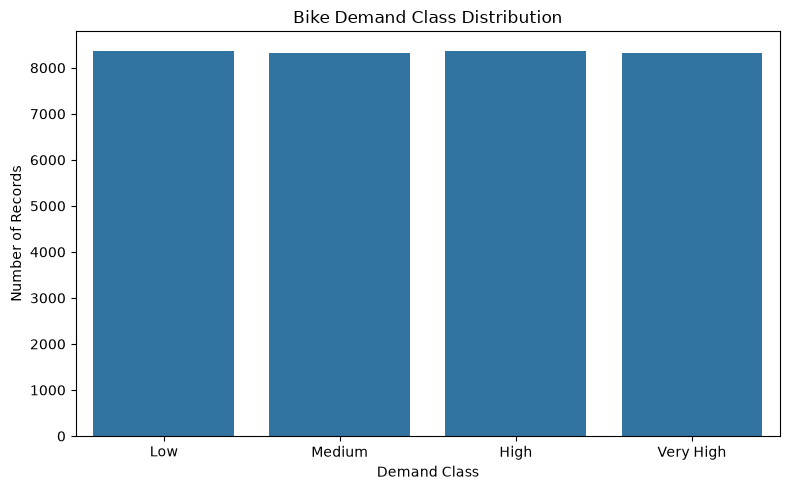

In [11]:
# Target Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="demand_class",
    order=["Low", "Medium", "High", "Very High"]
)

plt.title("Bike Demand Class Distribution")
plt.xlabel("Demand Class")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [12]:
#  Separate Features and Target
X = df.drop(
    columns=["count", "demand_class", "datetime"]
)

y = df["demand_class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (33379, 19)
Target shape: (33379,)

Features:
['holiday', 'workingday', 'temp', 'feels_like', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'hour', 'dayofweek', 'month', 'year', 'is_rush_hour']


In [13]:
#  Identify Numerical and Categorical Features

categorical_features = X.select_dtypes(
    include=["str"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['weather_main']

Numerical Features:
['holiday', 'workingday', 'temp', 'feels_like', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'wind_deg', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'dayofweek', 'month', 'year', 'is_rush_hour']


In [14]:
#  Stratified Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training set: (26703, 19)
Testing set : (6676, 19)

Training class distribution:
demand_class
Low          0.250871
Medium       0.249185
High         0.250758
Very High    0.249185
Name: proportion, dtype: float64

Testing class distribution:
demand_class
Low          0.250899
Medium       0.249251
High         0.250749
Very High    0.249101
Name: proportion, dtype: float64


In [15]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed.")
print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Preprocessing completed.
Processed training shape: (26703, 29)
Processed testing shape : (6676, 29)


In [16]:
#  Encode Target Classes

class_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2,
    "Very High": 3
}

y_train_encoded = y_train.map(class_mapping)
y_test_encoded = y_test.map(class_mapping)

print("Class Mapping:")
print(class_mapping)

print("\nEncoded target sample:")
print(y_train_encoded.head())

Class Mapping:
{'Low': 0, 'Medium': 1, 'High': 2, 'Very High': 3}

Encoded target sample:
15488    0
18518    0
2061     0
21410    1
29724    2
Name: demand_class, dtype: category
Categories (4, int64): [0 < 1 < 2 < 3]


In [17]:
#  Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

logistic_model.fit(
    X_train_processed,
    y_train_encoded
)

logistic_pred = logistic_model.predict(X_test_processed)
logistic_proba = logistic_model.predict_proba(X_test_processed)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [18]:
# Cell 18 — Logistic Regression Evaluation

logistic_accuracy = accuracy_score(
    y_test_encoded,
    logistic_pred
)

logistic_precision = precision_score(
    y_test_encoded,
    logistic_pred,
    average="weighted"
)

logistic_recall = recall_score(
    y_test_encoded,
    logistic_pred,
    average="weighted"
)

logistic_f1 = f1_score(
    y_test_encoded,
    logistic_pred,
    average="weighted"
)

logistic_roc_auc = roc_auc_score(
    y_test_encoded,
    logistic_proba,
    multi_class="ovr"
)

print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")
print(f"ROC-AUC  : {logistic_roc_auc:.4f}")

LOGISTIC REGRESSION
Accuracy : 0.5464
Precision: 0.5279
Recall   : 0.5464
F1 Score : 0.5340
ROC-AUC  : 0.7794


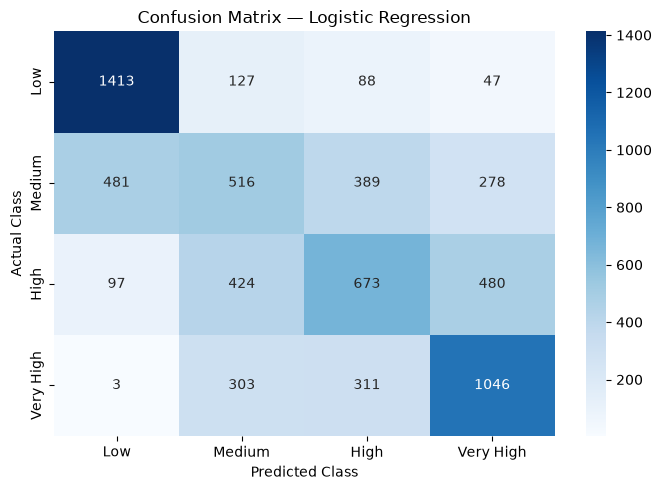

In [19]:
# Cell 19 — Logistic Regression Confusion Matrix

cm_logistic = confusion_matrix(
    y_test_encoded,
    logistic_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_mapping.keys(),
    yticklabels=class_mapping.keys()
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [20]:
# K-Nearest Neighbors Classifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_processed,
    y_train_encoded
)

knn_pred = knn_model.predict(X_test_processed)
knn_proba = knn_model.predict_proba(X_test_processed)

print("KNN Classifier trained successfully.")

KNN Classifier trained successfully.


In [21]:
#  KNN Evaluation

knn_accuracy = accuracy_score(
    y_test_encoded,
    knn_pred
)

knn_precision = precision_score(
    y_test_encoded,
    knn_pred,
    average="weighted"
)

knn_recall = recall_score(
    y_test_encoded,
    knn_pred,
    average="weighted"
)

knn_f1 = f1_score(
    y_test_encoded,
    knn_pred,
    average="weighted"
)

knn_roc_auc = roc_auc_score(
    y_test_encoded,
    knn_proba,
    multi_class="ovr"
)

print("=" * 60)
print("K-NEAREST NEIGHBORS")
print("=" * 60)

print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1 Score : {knn_f1:.4f}")
print(f"ROC-AUC  : {knn_roc_auc:.4f}")

K-NEAREST NEIGHBORS
Accuracy : 0.6663
Precision: 0.6655
Recall   : 0.6663
F1 Score : 0.6642
ROC-AUC  : 0.8668


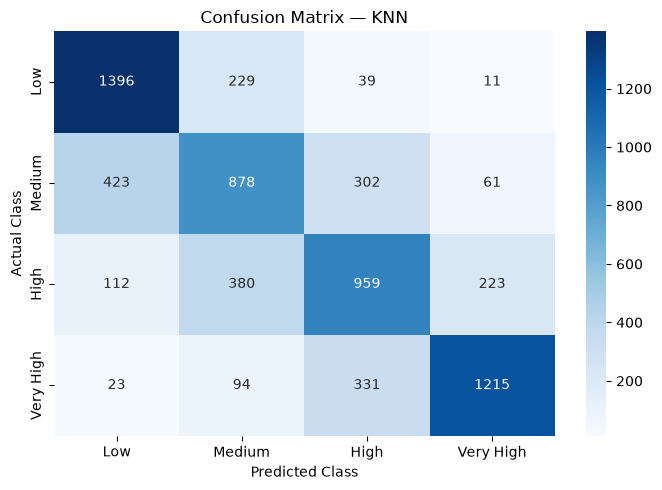

In [22]:
#  KNN Confusion Matrix

cm_knn = confusion_matrix(
    y_test_encoded,
    knn_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_mapping.keys(),
    yticklabels=class_mapping.keys()
)

plt.title("Confusion Matrix — KNN")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [23]:
# Gaussian Naive Bayes

nb_model = GaussianNB()

nb_model.fit(
    X_train_processed,
    y_train_encoded
)

nb_pred = nb_model.predict(X_test_processed)
nb_proba = nb_model.predict_proba(X_test_processed)

print("Gaussian Naive Bayes trained successfully.")

Gaussian Naive Bayes trained successfully.


In [24]:
#  Gaussian Naive Bayes Evaluation

nb_accuracy = accuracy_score(
    y_test_encoded,
    nb_pred
)

nb_precision = precision_score(
    y_test_encoded,
    nb_pred,
    average="weighted"
)

nb_recall = recall_score(
    y_test_encoded,
    nb_pred,
    average="weighted"
)

nb_f1 = f1_score(
    y_test_encoded,
    nb_pred,
    average="weighted"
)

nb_roc_auc = roc_auc_score(
    y_test_encoded,
    nb_proba,
    multi_class="ovr"
)

print("=" * 60)
print("GAUSSIAN NAIVE BAYES")
print("=" * 60)

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")
print(f"ROC-AUC  : {nb_roc_auc:.4f}")

GAUSSIAN NAIVE BAYES
Accuracy : 0.3002
Precision: 0.3201
Recall   : 0.3002
F1 Score : 0.2088
ROC-AUC  : 0.6799


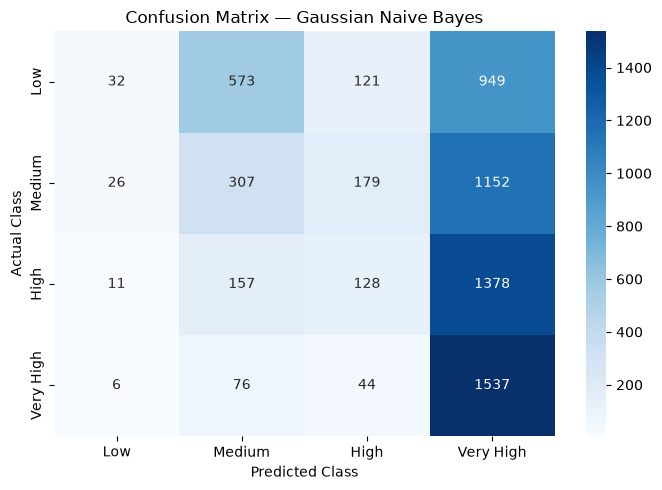

In [25]:
#  Gaussian Naive Bayes Confusion Matrix

cm_nb = confusion_matrix(
    y_test_encoded,
    nb_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_mapping.keys(),
    yticklabels=class_mapping.keys()
)

plt.title("Confusion Matrix — Gaussian Naive Bayes")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [26]:
# Decision Tree Classifier

dt_classifier = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=None
)

dt_classifier.fit(
    X_train_processed,
    y_train_encoded
)

dt_classifier_pred = dt_classifier.predict(
    X_test_processed
)

dt_classifier_proba = dt_classifier.predict_proba(
    X_test_processed
)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [27]:
# Decision Tree Evaluation

dt_accuracy = accuracy_score(
    y_test_encoded,
    dt_classifier_pred
)

dt_precision = precision_score(
    y_test_encoded,
    dt_classifier_pred,
    average="weighted"
)

dt_recall = recall_score(
    y_test_encoded,
    dt_classifier_pred,
    average="weighted"
)

dt_f1 = f1_score(
    y_test_encoded,
    dt_classifier_pred,
    average="weighted"
)

dt_roc_auc = roc_auc_score(
    y_test_encoded,
    dt_classifier_proba,
    multi_class="ovr"
)

print("=" * 60)
print("DECISION TREE CLASSIFIER")
print("=" * 60)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_roc_auc:.4f}")

DECISION TREE CLASSIFIER
Accuracy : 0.7882
Precision: 0.7882
Recall   : 0.7882
F1 Score : 0.7882
ROC-AUC  : 0.8588


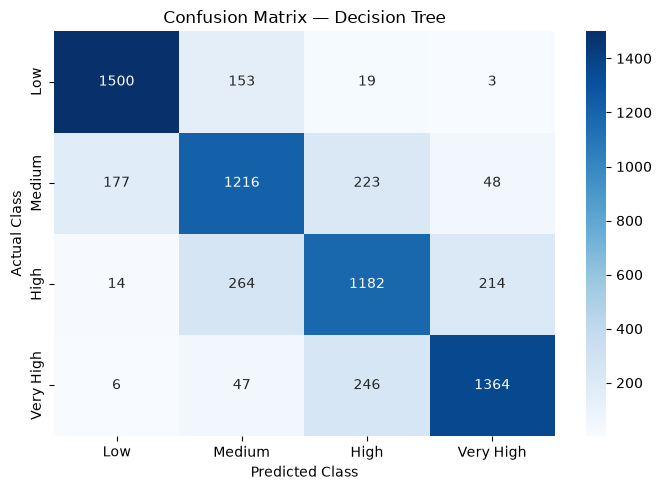

In [28]:
# Decision Tree Confusion Matrix

cm_dt = confusion_matrix(
    y_test_encoded,
    dt_classifier_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_mapping.keys(),
    yticklabels=class_mapping.keys()
)

plt.title("Confusion Matrix — Decision Tree")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [37]:
# Cell 29 — Support Vector Machine (fast linear SVM via SGD)

from sklearn.linear_model import SGDClassifier

svm_model = SGDClassifier(
    loss="hinge",        # linear SVM loss
    alpha=0.0001,
    random_state=RANDOM_STATE,
    max_iter=1000,
    tol=1e-3,
    n_jobs=-1             # use all CPU cores
)

svm_model.fit(
    X_train_processed,
    y_train_encoded
)

svm_pred = svm_model.predict(
    X_test_processed
)

# Decision scores for ROC-AUC
svm_scores = svm_model.decision_function(
    X_test_processed
)

print("Support Vector Machine trained successfully.")

Support Vector Machine trained successfully.


In [40]:
# Cell 30 — SVM Evaluation

svm_accuracy = accuracy_score(
    y_test_encoded,
    svm_pred
)

svm_precision = precision_score(
    y_test_encoded,
    svm_pred,
    average="weighted"
)

svm_recall = recall_score(
    y_test_encoded,
    svm_pred,
    average="weighted"
)

svm_f1 = f1_score(
    y_test_encoded,
    svm_pred,
    average="weighted"
)

# Multiclass One-vs-Rest ROC-AUC using SVM decision scores
from sklearn.preprocessing import label_binarize

y_test_binary = label_binarize(
    y_test_encoded,
    classes=[0, 1, 2, 3]
)

roc_auc_per_class = []

for i in range(4):
    auc = roc_auc_score(
        y_test_binary[:, i],
        svm_scores[:, i]
    )
    roc_auc_per_class.append(auc)

svm_roc_auc = np.average(
    roc_auc_per_class,
    weights=np.bincount(y_test_encoded)
)

print("=" * 60)
print("SUPPORT VECTOR MACHINE — SGD HINGE")
print("=" * 60)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")
print(f"ROC-AUC  : {svm_roc_auc:.4f}")

SUPPORT VECTOR MACHINE — SGD HINGE
Accuracy : 0.5163
Precision: 0.4957
Recall   : 0.5163
F1 Score : 0.4868
ROC-AUC  : 0.7355


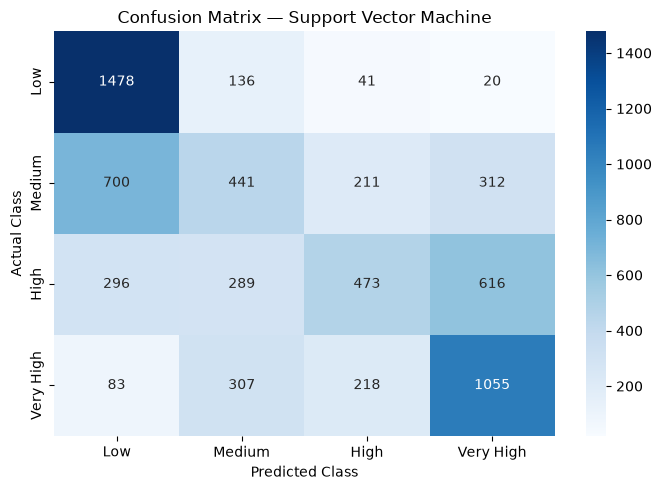

In [41]:
# Cell 31 — SVM Confusion Matrix

cm_svm = confusion_matrix(
    y_test_encoded,
    svm_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_mapping.keys(),
    yticklabels=class_mapping.keys()
)

plt.title("Confusion Matrix — Support Vector Machine")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [42]:
#  Classification Comparison Table

classification_results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1 Score": logistic_f1,
        "ROC-AUC": logistic_roc_auc
    },
    {
        "Model": "KNN",
        "Accuracy": knn_accuracy,
        "Precision": knn_precision,
        "Recall": knn_recall,
        "F1 Score": knn_f1,
        "ROC-AUC": knn_roc_auc
    },
    {
        "Model": "Gaussian Naive Bayes",
        "Accuracy": nb_accuracy,
        "Precision": nb_precision,
        "Recall": nb_recall,
        "F1 Score": nb_f1,
        "ROC-AUC": nb_roc_auc
    },
    {
        "Model": "Decision Tree",
        "Accuracy": dt_accuracy,
        "Precision": dt_precision,
        "Recall": dt_recall,
        "F1 Score": dt_f1,
        "ROC-AUC": dt_roc_auc
    },
    {
        "Model": "SVM",
        "Accuracy": svm_accuracy,
        "Precision": svm_precision,
        "Recall": svm_recall,
        "F1 Score": svm_f1,
        "ROC-AUC": svm_roc_auc
    }
]

classification_results_df = pd.DataFrame(
    classification_results
)

classification_results_df = classification_results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

classification_results_df.insert(
    0,
    "Rank",
    range(1, len(classification_results_df) + 1)
)

display(
    classification_results_df.round(4)
)

,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,Decision Tree,0.7882,0.7882,0.7882,0.7882,0.8588
1,2,KNN,0.6663,0.6655,0.6663,0.6642,0.8668
2,3,Logistic Regression,0.5464,0.5279,0.5464,0.5340,0.7794
3,4,SVM,0.5163,0.4957,0.5163,0.4868,0.7355
4,5,Gaussian Naive Bayes,0.3002,0.3201,0.3002,0.2088,0.6799


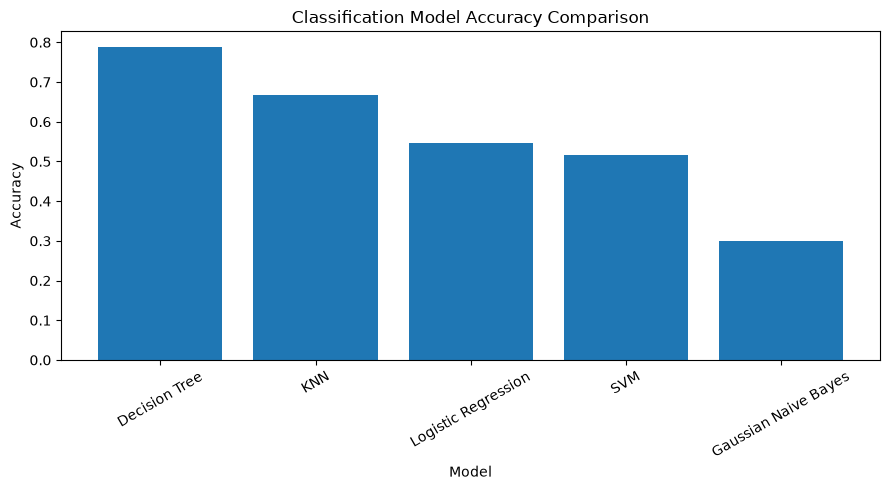

In [43]:
# — Accuracy Comparison

plt.figure(figsize=(9, 5))

plt.bar(
    classification_results_df["Model"],
    classification_results_df["Accuracy"]
)

plt.title("Classification Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

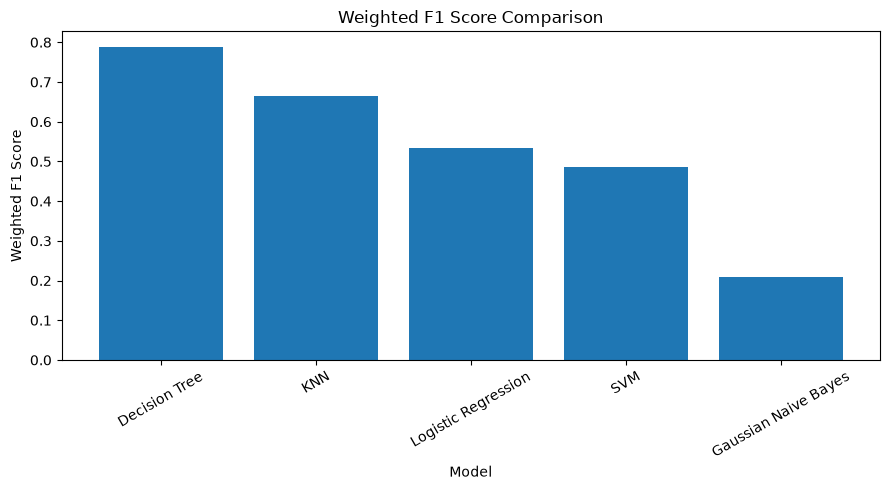

In [44]:
#  Weighted F1 Score Comparison

plt.figure(figsize=(9, 5))

plt.bar(
    classification_results_df["Model"],
    classification_results_df["F1 Score"]
)

plt.title("Weighted F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("Weighted F1 Score")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [45]:
#  Identify Top Two Models

top_two_models = classification_results_df.head(2)

print("Top 2 Classification Models:")
display(top_two_models)

Top 2 Classification Models:


,Rank,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,1,Decision Tree,0.788197,0.788237,0.788197,0.788181,0.858774
1,2,KNN,0.666267,0.665542,0.666267,0.664199,0.866754


In [47]:
#  5-Fold Cross-Validation for Top Two Models
from sklearn.model_selection import cross_val_score

print("cross_val_score imported successfully.")
models_for_cv = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "Gaussian Naive Bayes": nb_model,
    "Decision Tree": dt_classifier,
    "SVM": svm_model
}

cv_results = []

for model_name in top_two_models["Model"]:
    
    model = models_for_cv[model_name]
    
    scores = cross_val_score(
        model,
        X_train_processed,
        y_train_encoded,
        cv=5,
        scoring="accuracy"
    )
    
    cv_results.append({
        "Model": model_name,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

print("=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)

display(cv_results_df.round(4))

cross_val_score imported successfully.
5-FOLD CROSS-VALIDATION RESULTS


,Model,Mean CV Accuracy,Std CV Accuracy
0,Decision Tree,0.7730,0.0039
1,KNN,0.6619,0.0038


In [48]:
#  Final Classification Summary

best_model_name = classification_results_df.iloc[0]["Model"]
best_accuracy = classification_results_df.iloc[0]["Accuracy"]
best_f1 = classification_results_df.iloc[0]["F1 Score"]

print("=" * 60)
print("CLASSIFICATION PART A — FINAL SUMMARY")
print("=" * 60)

print(f"Best Model based on Accuracy: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"Weighted F1: {best_f1:.4f}")

print("\nAll five Part-A algorithms have been implemented.")

CLASSIFICATION PART A — FINAL SUMMARY
Best Model based on Accuracy: Decision Tree
Accuracy: 0.7882
Weighted F1: 0.7882

All five Part-A algorithms have been implemented.
